In [2]:
import pandas as pd

github_raw = "https://raw.githubusercontent.com/Buket12345/climbing-ifsc-dsa210/main"
df = pd.read_csv(f"{github_raw}/final_dataset.csv")


In [7]:
country_season = (
    df.groupby(['country','season','gender'], as_index=False)
    .agg(
        mean_rank=('rank','mean'),
        events=('rank','size'),
        gdp_per_capita=('gdp_per_capita','mean')
    )
)

country_season['gender_encoded'] = country_season['gender'].map({'male':0,'female':1})


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = country_season[['gdp_per_capita', 'events', 'season', 'gender_encoded']]
y = country_season['mean_rank']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



lr = LinearRegression()
lr.fit(X_train, y_train)


y_pred = lr.predict(X_test)

print("Train R^2:", lr.score(X_train, y_train))
print("Test  R^2:", lr.score(X_test, y_test))

print("MSE:", mean_squared_error(y_test, y_pred))


Train R^2: 0.2088735388118016
Test  R^2: 0.23592458885832357
MSE: 263.8839796842545


In [13]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})
coefficients

,Feature,Coefficient
0,gdp_per_capita,-0.000063
1,events,-0.049511
2,season,0.333324
3,gender_encoded,-22.975864


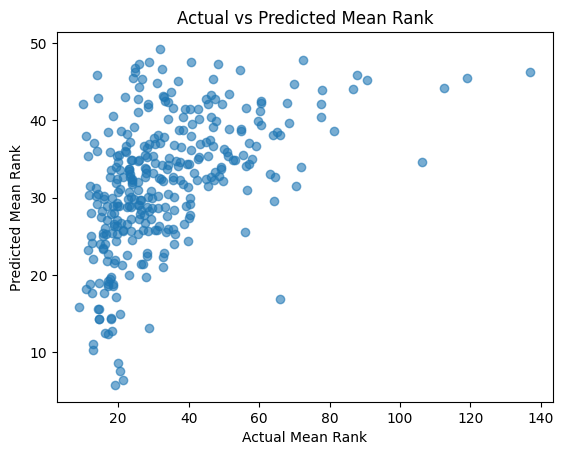

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Mean Rank")
plt.ylabel("Predicted Mean Rank")
plt.title("Actual vs Predicted Mean Rank")
plt.show()